<a href="https://colab.research.google.com/github/Spandana331/AIML_2026/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Machine Learning Terms and Metrics
"""
Module 1, Lab 2
In this lab, we demonstrate an important part of the Machine Learning pipeline using the Wine Quality Dataset.
The dataset contains physicochemical properties of wine samples and their corresponding quality ratings. Each sample includes attributes such as acidity, sugar content, alcohol percentage, pH level, and other chemical measurements.
The task is to predict the quality category of wine based on these attributes. For simplicity, we convert the quality score into a binary classification problem:
Quality ≥ 6 → Good Wine
Quality < 6 → Bad Wine
In this lab we will:
Load the dataset
Perform basic preprocessing
Train machine learning models
Evaluate model performance using common metrics
Split the dataset into training and testing sets
Apply cross-validation to obtain a more reliable estimate of model performance
We will use the scikit-learn library for dataset handling, model training, and evaluation.
"""
#Common Machine Learning Evaluation Metrics
"""

Machine learning models must be evaluated to understand how well they perform. Two common categories of evaluation metrics are classification metrics and regression metrics.

"""

In [ ]:
#Classification Metrics
"""

These metrics are used when the task involves predicting categories or labels, such as classifying wine quality as good or bad.

"""

In [ ]:
"""
1. Accuracy

Accuracy measures the proportion of correctly predicted samples out of the total number of samples.

           Correct Predictions
Accuracy = ---------------------
            Total Predictions

                TP + TN
  Accuracy = -----------------
             TP + TN + FP + FN

Where:

TP (True Positive) → Correctly predicted positive samples

TN (True Negative) → Correctly predicted negative samples

FP (False Positive) → Incorrectly predicted positive samples

FN (False Negative) → Incorrectly predicted negative samples


2. Precision

(How many predicted positives are actually positive?)

Precision measures the correctness of positive predictions.

                TP
Precision =  ----------
              TP + FP

High precision means the model makes fewer false positive errors.


3. Recall / Sensitivity

(How many actual positives did we correctly identify?)

Recall measures how many actual positive samples were correctly detected.

          TP
Recall= --------
         TP+FN


High recall means the model misses fewer positive cases.


4. F1-Score

The F1-score is the harmonic mean of Precision and Recall.

     2xPrecisionxRecall
F1=  ------------------------
      Precision+Recall


It is useful when we want to balance precision and recall, especially when the dataset is imbalanced.
"""





In [ ]:
#Regression Metrics
"""

Regression metrics are used when predicting continuous values instead of categories. Although wine quality prediction can be treated as classification, it can also be modeled as a regression problem when predicting the exact quality score.


1. Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted values.

              1  n
     MAE=    --- ∑ |yi - yi^|
              n i=1
A smaller MAE indicates better model performance.


2. Mean Squared Error (MSE)

MSE measures the average squared difference between actual and predicted values.

              1  n
     MAE=    --- ∑ (yi - yi^)2
              n i=1

Squaring the errors penalizes larger mistakes more strongly.


3. Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

            n
RMSE = ✓1/n ∑ (yi - yi^)2
            i=1


RMSE has the same units as the target variable and is easier to interpret.
"""


In [ ]:
#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
#Load the Wine Dataset
#Load the dataset and view the first few rows.
#We load the dataset into a pandas dataframe.
#This dataset contains chemical properties of wine such as acidity, pH, alcohol content, and sulphates.
#The target variable is wine quality.

data = pd.read_csv("/content/WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
#Explore the Dataset
"""
Before building a model, we must understand the dataset.

Here we check:
              .number of rows and columns
              .feature names
              .summary statistics
              """



In [ ]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nDataset Summary:")
print(data.describe())

Dataset Shape: (1143, 13)

Column Names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Dataset Summary:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      de

In [ ]:
#Convert Quality into a Classification Problem
"""
Wine quality values range from 0-10.
To simplify the problem we convert it into:
Good Wine → 1
Bad Wine → 0
This converts the task into a binary classification problem.
"""

In [ ]:
data["quality_label"] = data["quality"].apply(lambda x: 1 if x >= 6 else 0)

X = data.drop(["quality", "quality_label"], axis=1)
y = data["quality_label"]

In [ ]:
#Split Dataset into Train and Test
"""
Machine learning models must be evaluated on unseen data.
So we split the dataset:
80% Training Data
20% Test Data
Training data → model learns patterns
Test data → model performance evaluation
"""

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Implement 1-Nearest Neighbour
"""
The 1-Nearest Neighbour (1-NN) algorithm predicts the class of a new sample based on the closest training sample.
It is simple but very sensitive to noise.
"""

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred1 = knn1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
print("1-NN Accuracy:", acc1)

1-NN Accuracy: 0.6943231441048034


In [ ]:
#Implement 3-Nearest Neighbour
"""
The 3-Nearest Neighbour (3-NN) classifier uses the 3 closest neighbors and predicts the majority class.
This reduces noise and improves generalization.
"""

In [ ]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
y_pred3 = knn3.predict(X_test)
acc3 = accuracy_score(y_test, y_pred3)
print("3-NN Accuracy:", acc3)

3-NN Accuracy: 0.6375545851528385


In [ ]:
#Classification Metrics
"""
Classification metrics measure how well the model predicts class labels.
Metrics used:
Accuracy
Precision
Recall
F1 Score
"""


In [ ]:
accuracy = accuracy_score(y_test, y_pred3)
precision = precision_score(y_test, y_pred3)
recall = recall_score(y_test, y_pred3)
f1 = f1_score(y_test, y_pred3)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6375545851528385
Precision: 0.664179104477612
Recall: 0.7007874015748031
F1 Score: 0.6819923371647509


In [ ]:
#Regression Model
"""
In regression, we predict the exact wine quality score.

"""

In [ ]:
X_reg = data.drop(["quality","quality_label","Id"], axis=1)
y_reg = data["quality"]

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [ ]:
reg_model = KNeighborsRegressor(n_neighbors=3)
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

In [ ]:
#Regression Metrics
"""
Regression metrics measure prediction errors.
Metrics used:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)

"""

In [ ]:
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 0.5109170305676856
Mean Squared Error: 0.47113051916545373
Root Mean Squared Error: 0.6863894806634596


In [ ]:
#Visualization
"""
Visualizing feature distributions helps understand the dataset.
"""

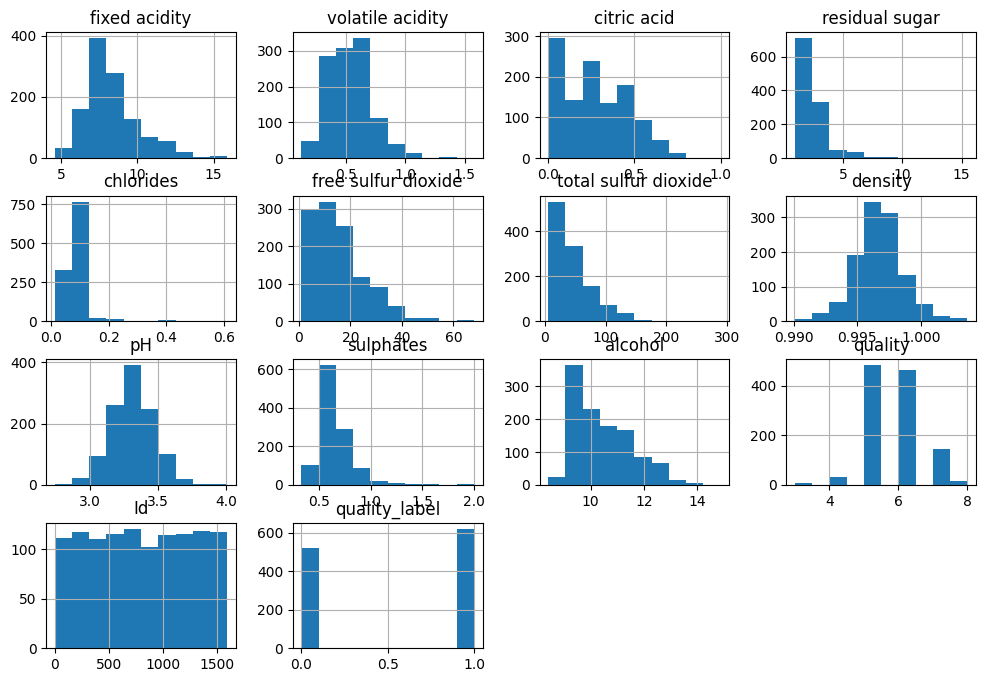

In [ ]:
data.hist(figsize=(12,8))
plt.show()

In [ ]:
#Confusion Matrix
"""
A confusion matrix helps us understand how well the classifier performs by showing:
True Positives (correctly predicted good wines)
True Negatives (correctly predicted bad wines)
False Positives
False Negatives
This gives more insight than accuracy alone.
"""

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred3)
print(cm)

[[57 45]
 [38 89]]


In [ ]:
#Visualization

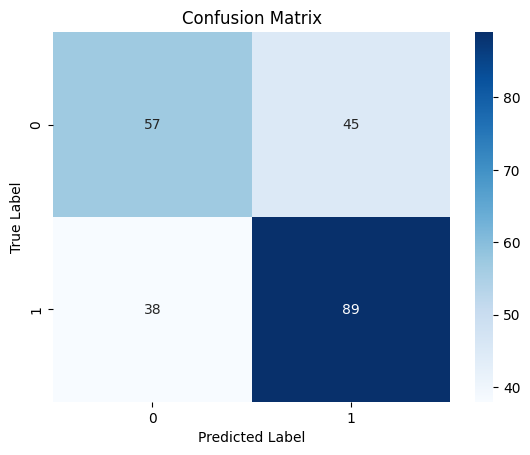

In [ ]:
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Accuracy vs K Graph
"""
The performance of the K-Nearest Neighbor algorithm depends on the value of K.
Small K → model may overfit
Large K → model may underfit
We test different values of K to find the best performance.

"""

In [ ]:
k_values = range(1, 21)
accuracy_values = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracy_values.append(acc)

In [ ]:
#Plot Graph

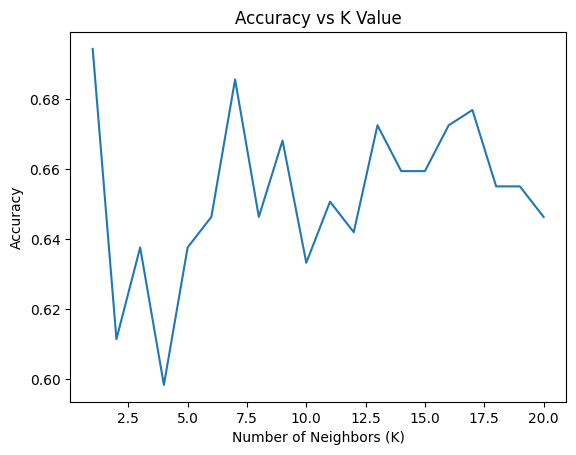

In [ ]:
plt.plot(k_values, accuracy_values)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.show()